In [155]:
import pandas as pd
import warnings


warnings.filterwarnings('ignore')

In [156]:
df=pd.read_csv('../Data/clean_df.csv')

In [157]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield_log,pesticides_cbrt
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37,10.508186,4.946087
1,1,Albania,Maize,1991,29068,1485.0,121.0,15.36,10.277428,4.946087
2,2,Albania,Maize,1992,24876,1485.0,121.0,16.06,10.121699,4.946087
3,3,Albania,Maize,1993,24185,1485.0,121.0,16.05,10.093529,4.946087
4,4,Albania,Maize,1994,25848,1485.0,201.0,16.96,10.160027,5.857766


In [158]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [159]:
df.dropna(inplace=True)
print(df.shape)

(28242, 9)


In [160]:
df['temp_stress'] = (df['avg_temp'] - 20).abs()
df['rain_temp_ratio'] = df['average_rain_fall_mm_per_year'] / (df['avg_temp'] + 1)
df['year_trend'] = df['Year'] - df['Year'].min()
df['rainfall_category'] = pd.cut(
    df['average_rain_fall_mm_per_year'],
    bins=[0, 500, 1000, 1500, 2000, 99999],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
df['temp_category'] = pd.cut(
    df['avg_temp'],
    bins=[-99, 10, 20, 30, 99],
    labels=['Cold', 'Mild', 'Warm', 'Hot']
)

print(df.shape)
print(df.columns.tolist())

(28242, 14)
['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'hg/ha_yield_log', 'pesticides_cbrt', 'temp_stress', 'rain_temp_ratio', 'year_trend', 'rainfall_category', 'temp_category']


In [161]:
df_lstm = df.sort_values(['Area', 'Item', 'Year']).reset_index(drop=True)
df_lstm.head(10)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield_log,pesticides_cbrt,temp_stress,rain_temp_ratio,year_trend,rainfall_category,temp_category
0,Albania,Maize,1990,36613,1485.0,121.00,16.37,10.508186,4.946087,3.63,85.492228,0,Medium,Mild
1,Albania,Maize,1991,29068,1485.0,121.00,15.36,10.277428,4.946087,4.64,90.770171,1,Medium,Mild
2,Albania,Maize,1992,24876,1485.0,121.00,16.06,10.121699,4.946087,3.94,87.045721,2,Medium,Mild
3,Albania,Maize,1993,24185,1485.0,121.00,16.05,10.093529,4.946087,3.95,87.096774,3,Medium,Mild
4,Albania,Maize,1994,25848,1485.0,201.00,16.96,10.160027,5.857766,3.04,82.683742,4,Medium,Mild
5,Albania,Maize,1995,31300,1485.0,251.00,15.67,10.351405,6.307994,4.33,89.082184,5,Medium,Mild
6,Albania,Maize,1996,32604,1485.0,313.96,15.64,10.392221,6.796596,4.36,89.242788,6,Medium,Mild
7,Albania,Maize,1997,31862,1485.0,376.93,15.90,10.369201,7.223598,4.10,87.869822,7,Medium,Mild
8,Albania,Maize,1998,33416,1485.0,439.89,16.27,10.416820,7.605271,3.73,85.987261,8,Medium,Mild
9,Albania,Maize,1999,37455,1485.0,502.86,16.57,10.530922,7.952110,3.43,84.519067,9,Medium,Mild


In [162]:
split=int(len(df_lstm)*0.8)

train_df=df_lstm[:split]
test_df=df_lstm[split:]

In [163]:
feature_cols = [col for col in df_lstm.columns
                if col not in ['Area', 'Item', 'hg/ha_yield',
                               'hg/ha_yield_log', 'Year']]

target = 'hg/ha_yield_log'

In [164]:
def create_sequences(df, feature_cols, target_col, window_size):
    X_seq, y_seq = [], []

    for (area, item), group in df.groupby(['Area', 'Item']):
        group = group.sort_values('Year').reset_index(drop=True)

        if len(group) <= window_size:
            continue

        X = group[feature_cols].values
        y = group[target_col].values

        for i in range(len(group) - window_size):
            X_seq.append(X[i:i+window_size])
            y_seq.append(y[i+window_size])

    return np.array(X_seq), np.array(y_seq)

x_train_seq, y_train_seq = create_sequences(train_df, feature_cols, 'hg/ha_yield_log', WINDOW_SIZE)
x_test_seq, y_test_seq = create_sequences(test_df, feature_cols, 'hg/ha_yield_log', WINDOW_SIZE)



In [165]:
x_test_seq

array([[[494.0, 16936.0, 23.76, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 22.14, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 26.82, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 22.14, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 26.29, ..., 7, 'Very Low', 'Warm']],

       [[494.0, 16936.0, 22.14, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 26.82, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 22.14, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 26.29, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 23.76, ..., 7, 'Very Low', 'Warm']],

       [[494.0, 16936.0, 26.82, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 22.14, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 26.29, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 23.76, ..., 7, 'Very Low', 'Warm'],
        [494.0, 16936.0, 25.16, ..., 7, 'Very Low', 'Warm']],

       ...,

       [[657.0, 3164.45, 20.7, ..., 16, 'Low', 'Warm'],
        [6

In [167]:
import category_encoders as ce

encoder=ce.TargetEncoder(cols=['Area','Item'])
x_train=encoder.fit_transform(x_train_seq,y_train)
x_test=encoder.transform(x_test_seq)

ValueError: Must pass 2-d input. shape=(20428, 5, 9)

In [131]:
numeric_cols = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_cbrt',
                'avg_temp', 'temp_stress', 'rain_temp_ratio', 'year_trend']
categorical_cols=['temp_category','rainfall_category']

categories=[
    ['Cold','Mild' ,'Warm' ,'Hot'],
    ['Very Low','Low','Medium','High','Very High']
]

In [132]:
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer

scale=StandardScaler()
encode=OrdinalEncoder(categories=categories)

preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), numeric_cols),
    ('encode',OrdinalEncoder(categories=categories),categorical_cols)
], remainder='passthrough')

x_train_transformed=preprocessor.fit_transform(x_train)
x_test_transformed=preprocessor.transform(x_test)

In [133]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout,Conv1D,MaxPooling1D

In [134]:
WINDOW_SIZE = 5
n_features = x_train.shape[1]

print(f"Window Size: {WINDOW_SIZE}")
print(f"Number of Features: {n_features}")

Window Size: 5
Number of Features: 12


In [135]:
import numpy as np

def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y.iloc[i+window_size])
    return np.array(X_seq), np.array(y_seq)

x_train_seq, y_train_seq = create_sequences(x_train_transformed, y_train, WINDOW_SIZE)
x_test_seq, y_test_seq = create_sequences(x_test_transformed, y_test, WINDOW_SIZE)

print(f"X_train_seq shape: {x_train_seq.shape}")
print(f"y_train_seq shape: {y_train_seq.shape}")

X_train_seq shape: (28237, 5, 12)
y_train_seq shape: (28237,)


In [136]:
model=Sequential()

model.add(Conv1D(filters=64,kernel_size=2,activation='relu',input_shape=(WINDOW_SIZE,n_features)))
model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(64,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(32,return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='linear'))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 4, 64)          │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 2, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,585 (185.88 KB)

 Trainable params: 47,585 (185.88 KB)

 Non-trainable params: 0 (0.00 B)

In [137]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stop=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.0001
)

In [138]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [139]:
history=model.fit(
    x_train_seq,y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/100
706/706 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 7.6776 - mae: 1.7631 - val_loss: 1.1820 - val_mae: 0.8873 - learning_rate: 0.0010
Epoch 2/100
706/706 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.9754 - mae: 1.1406 - val_loss: 1.1931 - val_mae: 0.8724 - learning_rate: 0.0010
Epoch 3/100
706/706 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 1.8550 - mae: 1.1117 - val_loss: 1.5421 - val_mae: 0.9547 - learning_rate: 0.0010
Epoch 4/100
706/706 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 1.7502 - mae: 1.0799 - val_loss: 1.2857 - val_mae: 0.8923 - learning_rate: 0.0010
Epoch 5/100
706/706 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 1.6730 - mae: 1.0602 - val_loss: 1.2624 - val_mae: 0.8853 - learning_rate: 0.0010
Epoch 6/100
706/706 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 1.4952 - mae: 1.0072 - val_loss: 1.2702 - val_mae: 0.8877 - learning_rate: 0.0010
Epoch 7/100
706/706 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 1.3996 - mae: 0.9852 - val_loss: 1.2572 - val_mae: 0.8839 - learning_

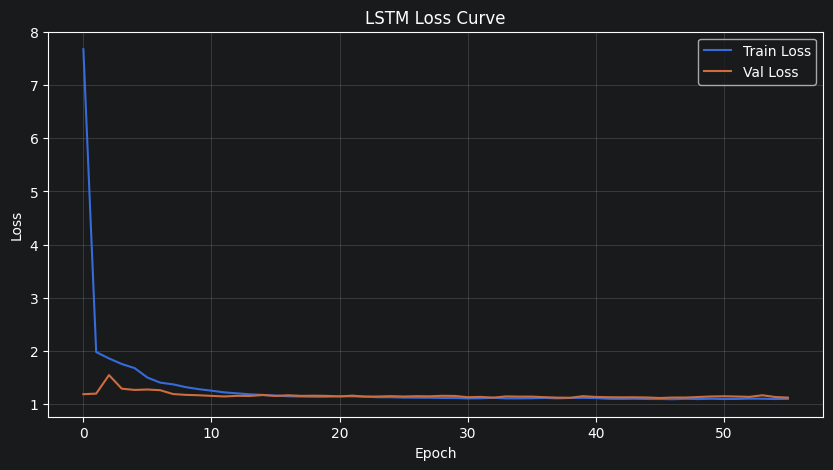

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [146]:
print("=== Test Data")
y_pred=model.predict(x_test_seq)
print("r2_score= ",r2_score(y_test_seq,y_pred))
print("MAE= ",mean_absolute_error(y_test_seq,y_pred))
print("MSE= ",mean_squared_error(y_test_seq,y_pred))
print("RMSE= ",root_mean_squared_error(y_test_seq,y_pred))

=== Test Data
883/883 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
r2_score=  -0.822486400604248
MAE=  77051.3125
MSE=  13155109888.0
RMSE=  114695.7265625
